### Chukchi Sea Bivalve question when are they being seen
Looking at samples from bivalve spawning event to see if the large cells are dropping out earlier

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np




In [11]:
## Some chat to scrape the data and get just the images identified as bivalve larvae 

from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
roi_csv = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/tag_class_roi_table_shellfishlarvae.csv")        # CSV with column: roi
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/SKQ202310S/merged/")     # directory containing *_adc_only.csv files
output_csv = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/matched_roi_master.csv")

roi_col = "roi"
roi_number_col = "RoiNumber"

# -----------------------------
# Load target ROIs
# -----------------------------
targets = pd.read_csv(roi_csv)

# Split ROI string into sample ID and ROI number
# Example: D20230727T033456_IFCB145_00036
targets["sample_id"] = targets[roi_col].str.rsplit("_", n=1).str[0]
targets["roi_number"] = targets[roi_col].str.rsplit("_", n=1).str[1].astype(int)

# Keep original search string as metadata
targets["original_search_criteria"] = targets[roi_col]

# -----------------------------
# Match ROIs across ADC files
# -----------------------------
matched_rows = []

for adc_file in data_dir.glob("*_adc_only.csv"):
    # Example filename:
    # D20230727T030526_IFCB145_adc_only.csv
    sample_id = adc_file.name.replace("_adc_only.csv", "")

    # Check whether this file contains any target ROIs
    file_targets = targets[targets["sample_id"] == sample_id]

    if file_targets.empty:
        continue

    df = pd.read_csv(adc_file)

    # Make sure RoiNumber is numeric
    df[roi_number_col] = df[roi_number_col].astype(int)

    # Merge to retain only matching ROI rows
    matched = df.merge(
        file_targets[["roi_number", "original_search_criteria"]],
        left_on=roi_number_col,
        right_on="roi_number",
        how="inner"
    )

    # Add useful metadata
    matched["source_file"] = adc_file.name
    matched["sample_id"] = sample_id

    # Drop helper column if desired
    matched = matched.drop(columns=["roi_number"])

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows")
print(f"Saved to {output_csv}")

Matched 308 rows
Saved to /Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/matched_roi_master.csv


In [12]:
df = pd.read_csv(Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/matched_roi_master.csv"))

In [19]:
df.head(n=20)


,trigger#,RoiNumber,PMTB,ADCtime,RunTime,InhibitTime,InhibitTimeDiff,VolumeAnalyzed,RoiType,RoiHeight,RoiWidth,RoiX,RoiY,original_search_criteria,source_file,sample_id
0,19,19,-0.004840,30.460505,30.486986,1.493008,0.082977,0.120808,1,332,392,716,6,D20230727T070822_IFCB145_00019,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
1,42,42,-0.004473,49.729277,49.759818,3.404787,0.083843,0.193146,1,284,360,684,0,D20230727T070822_IFCB145_00042,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
2,62,62,0.000103,60.047546,60.078264,5.060339,0.082587,0.229241,1,164,424,676,0,D20230727T070822_IFCB145_00062,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
3,62,62,0.000103,60.047546,60.078264,5.060339,0.082587,0.229241,1,164,424,676,0,D20230727T070822_IFCB145_00062,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
4,327,331,-0.003964,236.414763,236.450729,27.000358,0.082908,0.872710,1,276,304,740,390,D20230727T070822_IFCB145_00331,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
5,350,354,-0.004095,248.980601,249.016927,28.908166,0.082799,0.917120,1,308,320,732,270,D20230727T070822_IFCB145_00354,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
6,445,452,-0.004449,297.937030,297.974201,36.773945,0.082669,1.088334,1,340,336,716,222,D20230727T070822_IFCB145_00452,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
7,494,502,-0.004164,324.805422,324.845035,40.905182,0.083620,1.183083,1,284,336,748,342,D20230727T070822_IFCB145_00502,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
8,521,531,-0.004559,335.825470,335.864549,43.148819,0.082439,1.219649,1,276,376,684,174,D20230727T070822_IFCB145_00531,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145
9,849,861,-0.003895,559.510302,559.569896,70.324822,0.082678,2.038521,1,340,392,708,278,D20230727T070822_IFCB145_00861,D20230727T070822_IFCB145_adc_only.csv,D20230727T070822_IFCB145


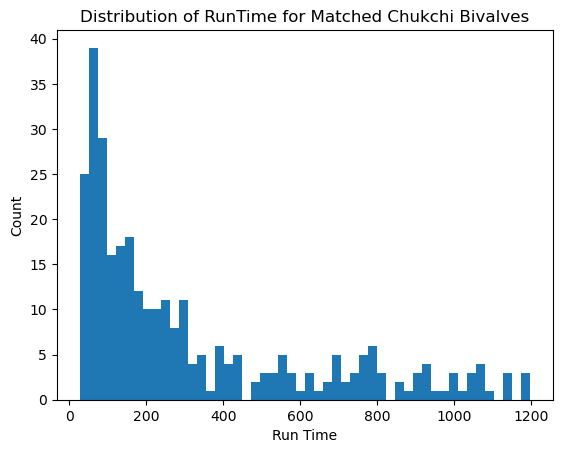

In [17]:
times = df["RunTime"].values
plt.hist(times, bins=50)
plt.xlabel("Run Time")
plt.ylabel("Count")
plt.title("Distribution of RunTime for Matched Chukchi Bivalves")
plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chuck_bivalve_runtime_histogram.png")
plt.show()


In [ ]:

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("../path/to/csv/files/")

runtime_col = "RunTime"
file_pattern = "*.csv"

# -----------------------------
# Collect RunTime values
# -----------------------------
all_runtimes = []

for file in data_dir.glob(file_pattern):
    try:
        df = pd.read_csv(file, usecols=[runtime_col])

        # Convert to numeric and drop bad values
        runtimes = pd.to_numeric(df[runtime_col], errors="coerce").dropna()

        all_runtimes.append(runtimes)

        print(f"Loaded {file.name}: {len(runtimes)} values")

    except Exception as e:
        print(f"Skipping {file.name}: {e}")

# -----------------------------
# Combine into one Series
# -----------------------------
if all_runtimes:
    runtime_series = pd.concat(all_runtimes, ignore_index=True)
else:
    raise ValueError("No valid RunTime data found.")

print(f"\nTotal RunTime values: {len(runtime_series)}")

# -----------------------------
# Plot histogram
# -----------------------------
plt.figure(figsize=(10, 6))

plt.hist(runtime_series, bins=100)

plt.xlabel("RunTime")
plt.ylabel("Count")
plt.title("Histogram of All RunTime Values")

plt.tight_layout()
#plt.savefig("../Figs/chukchi/AllRunTimesHist.png")
plt.show()